In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
torch.set_default_dtype(torch.float64)

device = torch.device('cuda')
%run func_defs.ipynb
%run NN_defs.ipynb


## Load model and data for the case of Smooth U for the derivative

In [5]:
k1 = 1.0; k2 = 2.0; z_dis = 1.0; nz = 80 ; tf1=2;

model_file = f'./model/2layer_nz{nz}_tf{tf1}.pt'
data_file  = f'./data/2layer_k1{k1}_k2{k2}_nz{nz}.pt'

# load model
model_dat = torch.load(model_file, weights_only=False)
for key in model_dat:
    globals()[key] = model_dat[key]
model = rebuild_nn()[0].to(device)
model.eval()
print(f"Model — layers: {model_dat['layers']}, nodes: {model_dat['nodes']}")

# load data
dat   = torch.load(data_file, weights_only=True)
stau  = dat['stau']   # (N, 2)
W     = dat['W']      # (N, 1)
zz    = dat['z']      # (N,)
tt    = dat['t']      # (N,)
print(f'Data loaded — N={stau.shape[0]}')


Model — layers: 4, nodes: 64
Data loaded — N=8100


## Reconstruct U(z, t) from data and model

In [7]:
# recover unique z and t axes
z_vals = torch.unique(zz)   # (nz+1,)
t_vals = torch.unique(tt)   # (n_sub_t,)
nz_out = z_vals.shape[0]
nt_out = t_vals.shape[0]

# U_true from saved W: U = W * t, reshape to (nz+1, n_sub_t)
U_true = (W.squeeze(1) * tt).reshape(nz_out, nt_out)

# build 4-input tensor matching training
kratio = dat['kratio']
z_disv = dat['zdis']
train  = torch.stack([stau[:, 0], stau[:, 1], kratio, z_disv], dim=-1)

# model prediction
with torch.no_grad():
    W_pred = model(train).squeeze(1)
U_pred = (W_pred * tt).reshape(nz_out, nt_out)

print(f'U_true shape: {U_true.shape}')
print(f'U_pred shape: {U_pred.shape}')


U_true shape: torch.Size([81, 100])
U_pred shape: torch.Size([81, 100])


## Errors

In [8]:
abs_err = torch.abs(U_pred - U_true)
rel_err = abs_err / torch.clamp(torch.abs(U_true), min=1.0)

print(f'Max abs error:  {abs_err.max().item():.4e}')
print(f'Mean abs error: {abs_err.mean().item():.4e}')
print(f'Max rel error:  {rel_err.max().item():.4e}')
print(f'Mean rel error: {rel_err.mean().item():.4e}')


Max abs error:  4.3182e-04
Mean abs error: 1.1619e-05
Max rel error:  4.3182e-04
Mean rel error: 1.1619e-05


## Plots

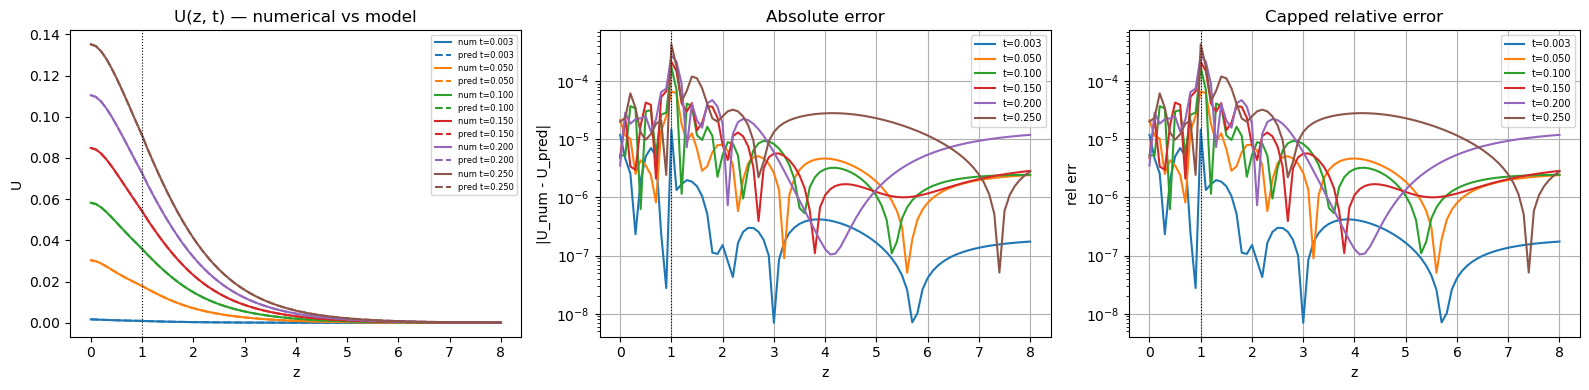

In [9]:
z_cpu  = z_vals.cpu(); t_cpu = t_vals.cpu()
Ut_cpu = U_true.cpu(); Up_cpu = U_pred.cpu()
ae_cpu = abs_err.cpu(); re_cpu = rel_err.cpu()

idx = torch.linspace(0, nt_out-1, 6).long()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# numerical vs predicted
ax = axes[0]
for i in idx:
    c = ax._get_lines.get_next_color()
    ax.plot(z_cpu, Ut_cpu[:, i], '-',  color=c, label=f'num t={t_cpu[i]:.3f}')
    ax.plot(z_cpu, Up_cpu[:, i], '--', color=c, label=f'pred t={t_cpu[i]:.3f}')
ax.axvline(z_dis, color='k', linestyle=':', linewidth=0.8)
ax.set_xlabel('z'); ax.set_ylabel('U')
ax.set_title('U(z, t) — numerical vs model')
ax.legend(fontsize=6)

# absolute error
ax = axes[1]
for i in idx:
    ax.semilogy(z_cpu, ae_cpu[:, i], label=f't={t_cpu[i]:.3f}')
ax.axvline(z_dis, color='k', linestyle=':', linewidth=0.8)
ax.set_xlabel('z'); ax.set_ylabel('|U_num - U_pred|')
ax.set_title('Absolute error')
ax.legend(fontsize=7); ax.grid(True)

# relative error
ax = axes[2]
for i in idx:
    ax.semilogy(z_cpu, re_cpu[:, i], label=f't={t_cpu[i]:.3f}')
ax.axvline(z_dis, color='k', linestyle=':', linewidth=0.8)
ax.set_xlabel('z'); ax.set_ylabel('rel err')
ax.set_title('Capped relative error')
ax.legend(fontsize=7); ax.grid(True)

plt.tight_layout()
plt.show()


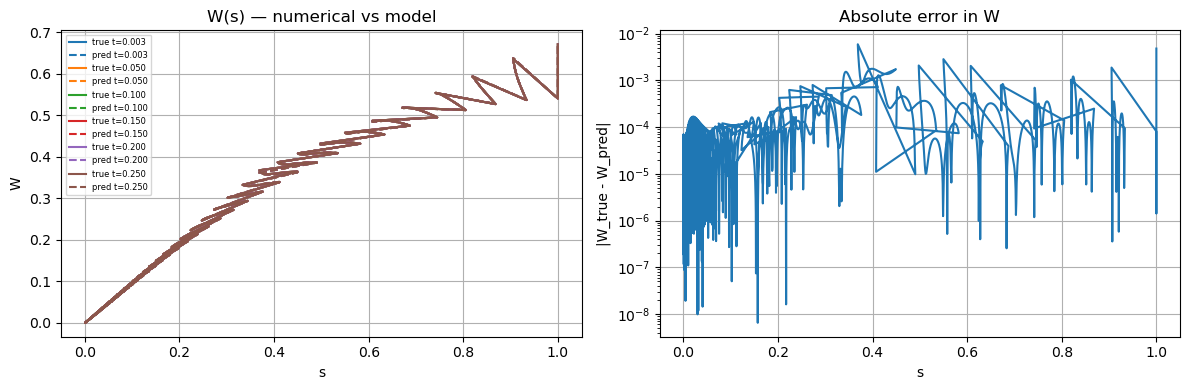

In [11]:
# plot W vs s
idx = torch.linspace(0, nt_out-1, 6).long()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
for i in idx:
    c = ax._get_lines.get_next_color()
    ax.plot(stau[:, 0].cpu(), W.squeeze(1).cpu(), '-',  color=c, label=f'true t={t_vals[i]:.3f}')
    ax.plot(stau[:, 0].cpu(), W_pred.cpu(),        '--', color=c, label=f'pred t={t_vals[i]:.3f}')
ax.set_xlabel('s'); ax.set_ylabel('W')
ax.set_title('W(s) — numerical vs model')
ax.legend(fontsize=6); ax.grid(True)

ax = axes[1]
ax.semilogy(stau[:, 0].cpu(), torch.abs(W_pred - W.squeeze(1)).cpu())
ax.set_xlabel('s'); ax.set_ylabel('|W_true - W_pred|')
ax.set_title('Absolute error in W')
ax.grid(True)

plt.tight_layout()
plt.show()